# Anomaly Detection Model Insights and Comparative Evaluation
## Multi-Paradigm Comparison, Jaccard Overlap Analysis, and Latent Representations

---

### Overview
This notebook evaluates the outputs of five distinct anomaly detection paradigms across 1,000,000 payment transactions.
We evaluate:
1. Detection rates across heterogeneous model paradigms.
2. Pairwise Intersection over Union (Jaccard similarity) and shared anomaly volumes.
3. Consensus vote distribution and majority filtering mechanics.
4. Empirical feature comparison between consensus anomalies and normal transactions.
5. Deep Generative (VAE) reconstruction error distributions and LightGBM probability boundaries.


In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

data_path = Path('data/transactions.csv') if Path('data/transactions.csv').exists() else Path('../data/transactions.csv')
reports_dir = Path('reports') if Path('reports').exists() else Path('../reports')

df = pd.read_csv(data_path)
print(f'Base dataset: {len(df):,} transactions')
print(f'Reports location: {reports_dir.resolve()}')


Base dataset: 1,000,000 transactions
Reports location: D:\int20h2026\test\reports


## 1. Multi-Model Output Loading and Summary Comparison
We load pre-computed anomaly predictions for all five paradigms and the consolidated majority voting ensemble.


In [2]:
model_files = {
    'Rule-Based': 'submission_rule_based.csv',
    'Clustering': 'submission_clustering.csv',
    'Isolation Forest': 'submission_isolation_forest.csv',
    'VAE': 'submission_vae.csv',
    'Semi-Supervised': 'submission_semi_supervised.csv',
    'Meta-Ensemble': 'submission_ensemble.csv'
}

predictions = {}
summary_rows = []

for name, filename in model_files.items():
    file_path = reports_dir / filename
    if file_path.exists():
        pred_df = pd.read_csv(file_path)
        preds = pred_df['is_anomaly'].values.astype(int)
        predictions[name] = preds
        count = int(preds.sum())
        rate = float(count / len(preds) * 100)
        summary_rows.append({
            'Model': name,
            'Anomaly Count': count,
            'Anomaly Rate (%)': round(rate, 2),
            'Total Samples': len(preds)
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))


           Model  Anomaly Count  Anomaly Rate (%)  Total Samples
      Rule-Based          96274              9.63        1000000
      Clustering          48942              4.89        1000000
Isolation Forest          53824              5.38        1000000
             VAE          41838              4.18        1000000
 Semi-Supervised          50833              5.08        1000000
   Meta-Ensemble          23341              2.33        1000000


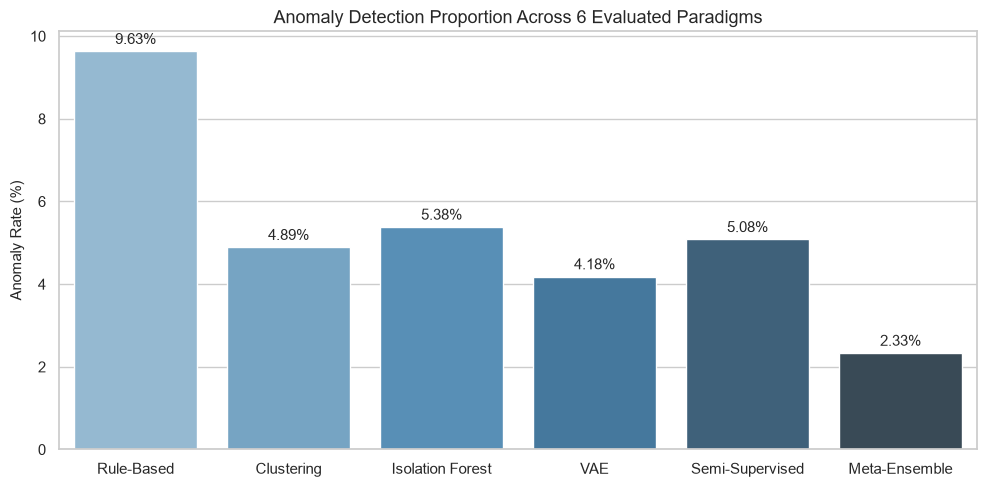

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=summary_df, x='Model', y='Anomaly Rate (%)', ax=ax, palette='Blues_d')
ax.set_title('Anomaly Detection Proportion Across 6 Evaluated Paradigms')
ax.set_ylabel('Anomaly Rate (%)')
ax.set_xlabel('')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()


## 2. Pairwise Jaccard Similarity and Shared Anomaly Matrices
We compute the Intersection over Union (IoU) of positive predictions to evaluate model overlap without distortion from negative class imbalance.


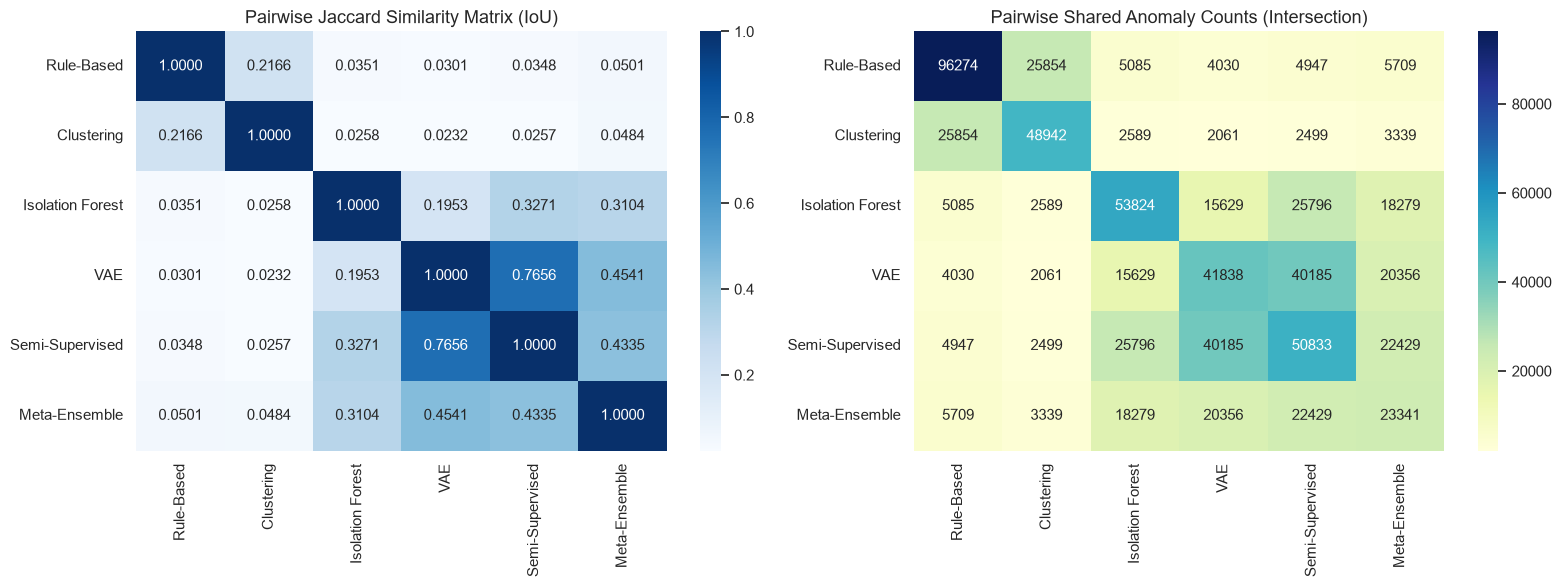

In [4]:
model_names = list(predictions.keys())
n_models = len(model_names)
jaccard_matrix = np.zeros((n_models, n_models), dtype=float)
overlap_matrix = np.zeros((n_models, n_models), dtype=int)

for i, m1 in enumerate(model_names):
    for j, m2 in enumerate(model_names):
        p1 = predictions[m1].astype(bool)
        p2 = predictions[m2].astype(bool)
        inter = int(np.sum(p1 & p2))
        union = int(np.sum(p1 | p2))
        jaccard_matrix[i, j] = inter / union if union > 0 else 0.0
        overlap_matrix[i, j] = inter

jaccard_df = pd.DataFrame(jaccard_matrix, index=model_names, columns=model_names)
overlap_df = pd.DataFrame(overlap_matrix, index=model_names, columns=model_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(jaccard_df, annot=True, fmt='.4f', cmap='Blues', cbar=True, ax=axes[0])
axes[0].set_title('Pairwise Jaccard Similarity Matrix (IoU)')

sns.heatmap(overlap_df, annot=True, fmt='d', cmap='YlGnBu', cbar=True, ax=axes[1])
axes[1].set_title('Pairwise Shared Anomaly Counts (Intersection)')
plt.tight_layout()
plt.show()


## 3. Consensus Vote Distribution and Majority Filtering
We analyze the distribution of model agreement across all 1,000,000 transactions.


 Models in Agreement  Transaction Count  Proportion (%)
                   0             810079           81.01
                   1             111561           11.16
                   2              57987            5.80
                   3              17714            1.77
                   4               2261            0.23
                   5                398            0.04


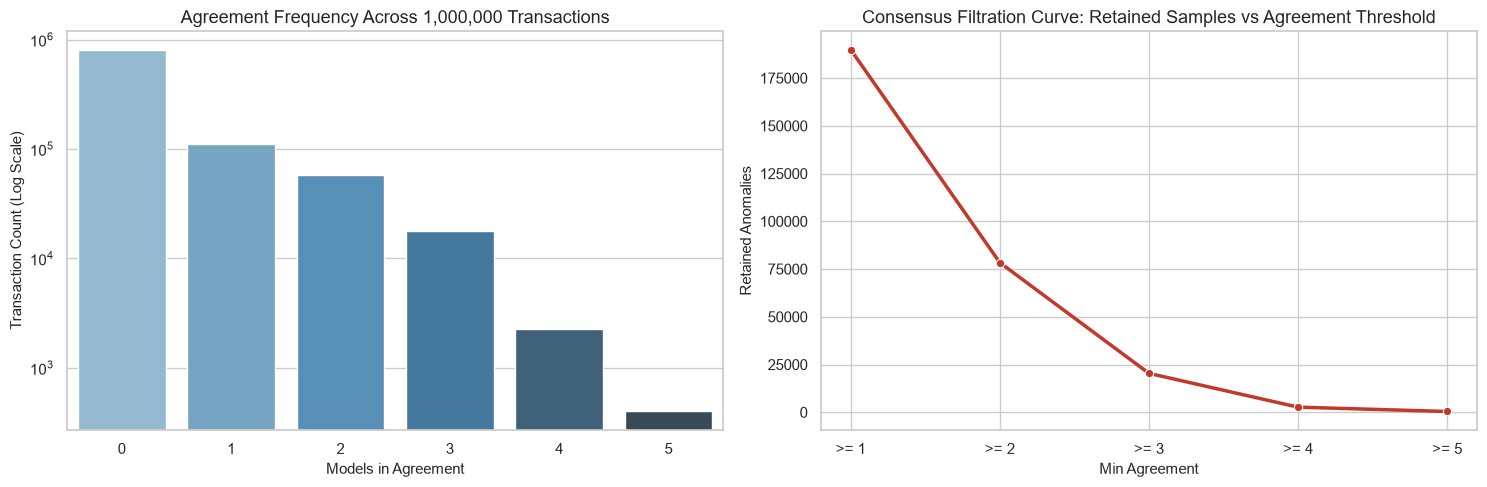

In [5]:
base_model_names = ['Rule-Based', 'Clustering', 'Isolation Forest', 'VAE', 'Semi-Supervised']
base_vote_matrix = np.column_stack([predictions[m] for m in base_model_names if m in predictions])
vote_counts = base_vote_matrix.sum(axis=1)

vote_dist = pd.DataFrame({
    'Models in Agreement': list(range(base_vote_matrix.shape[1] + 1)),
    'Transaction Count': [(vote_counts == k).sum() for k in range(base_vote_matrix.shape[1] + 1)]
})
vote_dist['Proportion (%)'] = (vote_dist['Transaction Count'] / len(df) * 100).round(2)
print(vote_dist.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=vote_dist, x='Models in Agreement', y='Transaction Count', ax=axes[0], palette='Blues_d')
axes[0].set_title('Agreement Frequency Across 1,000,000 Transactions')
axes[0].set_yscale('log')
axes[0].set_ylabel('Transaction Count (Log Scale)')

cum_counts = [int((vote_counts >= k).sum()) for k in range(1, base_vote_matrix.shape[1] + 1)]
cum_df = pd.DataFrame({'Min Agreement': [f'>= {k}' for k in range(1, base_vote_matrix.shape[1] + 1)], 'Retained Count': cum_counts})
sns.lineplot(data=cum_df, x='Min Agreement', y='Retained Count', ax=axes[1], marker='o', color='#c0392b', linewidth=2.5)
axes[1].set_title('Consensus Filtration Curve: Retained Samples vs Agreement Threshold')
axes[1].set_ylabel('Retained Anomalies')

plt.tight_layout()
plt.show()


## 4. Empirical Profile of Detected Anomalies
We compare the operational and financial attributes of consensus anomalies vs normal transactions across multiple dimensions.


In [6]:
df['is_ensemble_anomaly'] = predictions['Meta-Ensemble'] if 'Meta-Ensemble' in predictions else (vote_counts >= 3).astype(int)
df['created_at'] = pd.to_datetime(df['created_at'], utc=True)
df['processed_at'] = pd.to_datetime(df['processed_at'], utc=True)
df['latency_sec'] = (df['processed_at'] - df['created_at']).dt.total_seconds()

fx_rates = {'USD': 1.0, 'EUR': 1.08, 'GBP': 1.27, 'UAH': 0.024, 'PLN': 0.25, 'CAD': 0.74, 'AUD': 0.65}
df['amount_usd'] = df['amount'] * df['currency'].map(lambda c: fx_rates.get(str(c).upper(), 1.0))
df['has_refund'] = df['has_refund'].astype(bool)
df['is_geo_mismatch'] = df['ip_country'] != df['bin_country']

profile = df.groupby('is_ensemble_anomaly').agg(
    volume=('order_id', 'count'),
    mean_amount_usd=('amount_usd', 'mean'),
    median_amount_usd=('amount_usd', 'median'),
    p95_amount_usd=('amount_usd', lambda x: np.percentile(x, 95)),
    mean_latency_sec=('latency_sec', 'mean'),
    median_latency_sec=('latency_sec', 'median'),
    p95_latency_sec=('latency_sec', lambda x: np.percentile(x, 95)),
    refund_rate=('has_refund', 'mean'),
    secured_3ds_rate=('is_secured', 'mean'),
    geo_mismatch_rate=('is_geo_mismatch', 'mean'),
    fail_rate=('status', lambda s: (s == 'fail').mean())
).reset_index()

profile['Class'] = profile['is_ensemble_anomaly'].map({0: 'Normal Population', 1: 'Consensus Anomalies'})
print(profile.round(3).to_string(index=False))


 is_ensemble_anomaly  volume  mean_amount_usd  median_amount_usd  p95_amount_usd  mean_latency_sec  median_latency_sec  p95_latency_sec  refund_rate  secured_3ds_rate  geo_mismatch_rate  fail_rate               Class
                   0  976659           47.454               20.0         121.656            33.695                 6.0             10.0        0.037             0.042              0.140      0.474   Normal Population
                   1   23341           59.153               20.0         185.000           105.137                 6.0             10.0        0.044             0.043              0.325      0.507 Consensus Anomalies


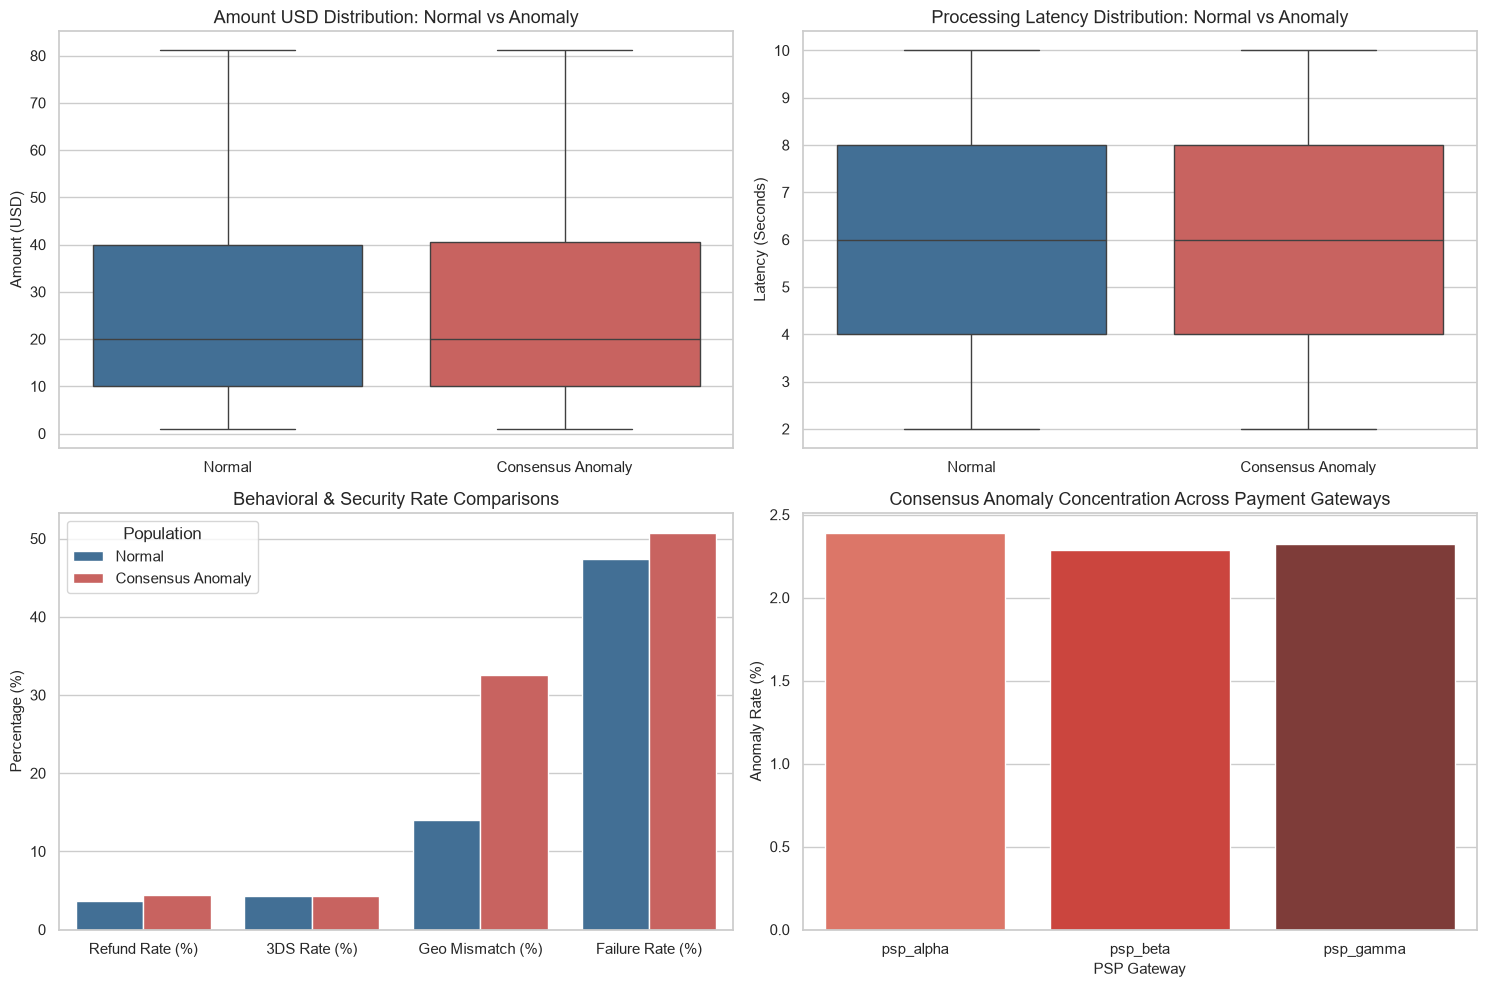

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(data=df, x='is_ensemble_anomaly', y='amount_usd', ax=axes[0, 0], palette=['#3470a3', '#d9534f'], showfliers=False)
axes[0, 0].set_xticklabels(['Normal', 'Consensus Anomaly'])
axes[0, 0].set_title('Amount USD Distribution: Normal vs Anomaly')
axes[0, 0].set_ylabel('Amount (USD)')
axes[0, 0].set_xlabel('')

sns.boxplot(data=df, x='is_ensemble_anomaly', y='latency_sec', ax=axes[0, 1], palette=['#3470a3', '#d9534f'], showfliers=False)
axes[0, 1].set_xticklabels(['Normal', 'Consensus Anomaly'])
axes[0, 1].set_title('Processing Latency Distribution: Normal vs Anomaly')
axes[0, 1].set_ylabel('Latency (Seconds)')
axes[0, 1].set_xlabel('')

rates_df = pd.DataFrame({
    'Rate Type': ['Refund Rate (%)', '3DS Rate (%)', 'Geo Mismatch (%)', 'Failure Rate (%)'],
    'Normal': [
        df[df['is_ensemble_anomaly'] == 0]['has_refund'].mean() * 100,
        df[df['is_ensemble_anomaly'] == 0]['is_secured'].mean() * 100,
        df[df['is_ensemble_anomaly'] == 0]['is_geo_mismatch'].mean() * 100,
        (df[df['is_ensemble_anomaly'] == 0]['status'] == 'fail').mean() * 100
    ],
    'Consensus Anomaly': [
        df[df['is_ensemble_anomaly'] == 1]['has_refund'].mean() * 100,
        df[df['is_ensemble_anomaly'] == 1]['is_secured'].mean() * 100,
        df[df['is_ensemble_anomaly'] == 1]['is_geo_mismatch'].mean() * 100,
        (df[df['is_ensemble_anomaly'] == 1]['status'] == 'fail').mean() * 100
    ]
}).melt(id_vars='Rate Type', var_name='Population', value_name='Percentage (%)')

sns.barplot(data=rates_df, x='Rate Type', y='Percentage (%)', hue='Population', ax=axes[1, 0], palette=['#3470a3', '#d9534f'])
axes[1, 0].set_title('Behavioral & Security Rate Comparisons')
axes[1, 0].set_xlabel('')

psp_anom = df.groupby('psp_id')['is_ensemble_anomaly'].mean().reset_index()
psp_anom['Anomaly Rate (%)'] = psp_anom['is_ensemble_anomaly'] * 100
sns.barplot(data=psp_anom, x='psp_id', y='Anomaly Rate (%)', ax=axes[1, 1], palette='Reds_d')
axes[1, 1].set_title('Consensus Anomaly Concentration Across Payment Gateways')
axes[1, 1].set_xlabel('PSP Gateway')
axes[1, 1].set_ylabel('Anomaly Rate (%)')

plt.tight_layout()
plt.show()
